In [2]:
from ultralytics import YOLO

In [3]:
model = YOLO("yolo26n.pt")
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [4]:
images = ["https://homl.info/soccer.jpg", "https://homl.info/traffic.jpg"]

In [6]:
results = model(images)
results


0: 640x640 4 persons, 1 sports ball, 216.9ms
1: 640x640 2 persons, 7 cars, 1 motorcycle, 8 trucks, 216.9ms
Speed: 4.3ms preprocess, 216.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [16]:
results[0].to_df()

name,class,confidence,box
str,i64,f64,struct[4]
"""person""",0,0.94183,"{381.47961,51.88379,548.42651,408.66998}"
"""person""",0,0.92973,"{235.37982,41.10529,365.81677,401.49677}"
"""sports ball""",32,0.92319,"{245.2524,286.02933,301.32626,342.65274}"
"""person""",0,0.86721,"{124.3973,18.01503,244.56067,406.89221}"
"""person""",0,0.68822,"{41.84154,83.86612,181.42615,402.33691}"


In [18]:
results[0].summary()

[{'name': 'person',
  'class': 0,
  'confidence': 0.94183,
  'box': {'x1': 381.47961, 'y1': 51.88379, 'x2': 548.42651, 'y2': 408.66998}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.92973,
  'box': {'x1': 235.37982, 'y1': 41.10529, 'x2': 365.81677, 'y2': 401.49677}},
 {'name': 'sports ball',
  'class': 32,
  'confidence': 0.92319,
  'box': {'x1': 245.2524, 'y1': 286.02933, 'x2': 301.32626, 'y2': 342.65274}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.86721,
  'box': {'x1': 124.3973, 'y1': 18.01503, 'x2': 244.56067, 'y2': 406.89221}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.68822,
  'box': {'x1': 41.84154, 'y1': 83.86612, 'x2': 181.42615, 'y2': 402.33691}}]

In [25]:
from pathlib import Path

image_dir = Path(r"C:\Users\user\Desktop\div\images")
image_path = image_dir / "qizlar.jpg"
image_path

WindowsPath('C:/Users/user/Desktop/div/images/qizlar.jpg')

In [26]:
results[0].save(image_path)

WindowsPath('C:/Users/user/Desktop/div/images/qizlar.jpg')

In [19]:
import PIL

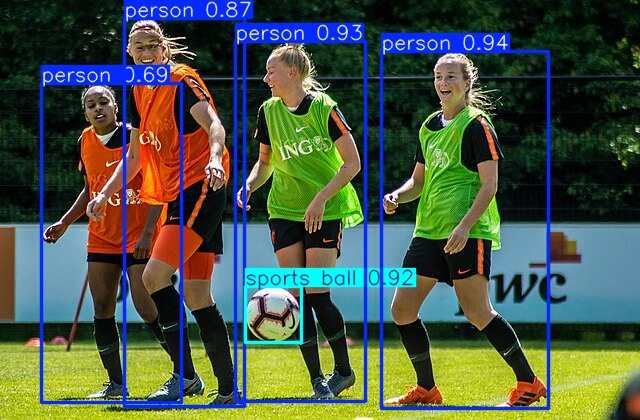

In [29]:
img = PIL.Image.open(image_path)
img

In [ ]:
my_video = "https://homl.info/cars.mp4"

results = model.track(source=my_video, stream=True, save=True)